   Rainfall  Temperature  Soil_Moisture   Soil_pH  Nitrogen  Phosphorus  \
0  0.577079     1.528892       0.501549 -0.542526 -1.347283   -0.244281   
1 -0.474170     0.630255      -0.717453  0.331844  0.137897   -1.057842   
2 -0.814329    -0.854449       0.000180  1.206215  0.546834    1.356104   
3 -0.782371     1.528892      -0.451363  0.532949  0.810878    0.144442   
4 -0.803937    -1.225625      -0.226755  0.681592  0.692414    0.871296   

   Irrigation  Crop_Area  Fertilizer  Pesticide  Sunlight  Crop_Diversity  \
0   -1.508541  -2.141981   -1.231144  -1.823204 -1.144160        0.693137   
1    1.423335   2.152128    0.117762   1.444803  1.547982        0.096585   
2    1.848923  -0.028065    0.342579   0.000000  0.471125        0.096585   
3    1.300073   0.383288    1.860098   1.444803  0.201911        2.482794   
4    1.726710   0.305967    1.860098   1.444803  0.201911        0.693137   

   Mechanization  Yield_Variance  
0       0.363784       -1.190426  
1       0.207976

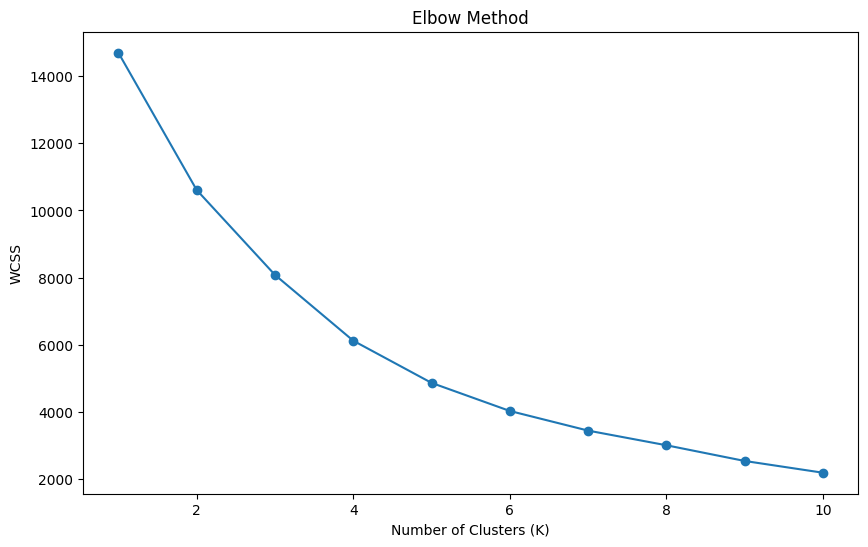

   Rainfall  Temperature  Soil_Moisture   Soil_pH  Nitrogen  Phosphorus  \
0  0.577079     1.528892       0.501549 -0.542526 -1.347283   -0.244281   
1 -0.474170     0.630255      -0.717453  0.331844  0.137897   -1.057842   
2 -0.814329    -0.854449       0.000180  1.206215  0.546834    1.356104   
3 -0.782371     1.528892      -0.451363  0.532949  0.810878    0.144442   
4 -0.803937    -1.225625      -0.226755  0.681592  0.692414    0.871296   

   Irrigation  Crop_Area  Fertilizer  Pesticide  Sunlight  Crop_Diversity  \
0   -1.508541  -2.141981   -1.231144  -1.823204 -1.144160        0.693137   
1    1.423335   2.152128    0.117762   1.444803  1.547982        0.096585   
2    1.848923  -0.028065    0.342579   0.000000  0.471125        0.096585   
3    1.300073   0.383288    1.860098   1.444803  0.201911        2.482794   
4    1.726710   0.305967    1.860098   1.444803  0.201911        0.693137   

   Mechanization  Yield_Variance  Cluster  
0       0.363784       -1.190426        1 

In [3]:
# =========================================
# PHASE 6 : K-MEANS CLUSTERING
# Elbow Method + Model Training
# =========================================

# -----------------------------------------
# Step 1 : Import Required Libraries
# -----------------------------------------

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# -----------------------------------------
# Step 2 : Load Final Selected Dataset
# -----------------------------------------

# Load dataset after feature selection
# This contains only important features

final_df = pd.read_csv("final_selected_features_dataset.csv")

print(final_df.head())
print("Dataset Shape:", final_df.shape)


# =========================================
# STEP 3 : ELBOW METHOD
# =========================================

# Elbow Method helps us find the best
# number of clusters (K)

# WCSS = Within Cluster Sum of Squares

wcss = []

for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        max_iter=300,
        n_init=10,
        random_state=42
    )
    
    kmeans.fit(final_df)
    
    # inertia_ gives WCSS value
    wcss.append(kmeans.inertia_)


# -----------------------------------------
# Step 4 : Plot Elbow Curve
# -----------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, 11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()


# =========================================
# STEP 5 : APPLY FINAL K-MEANS MODEL
# =========================================

# Choose best K after observing elbow graph
# Example:
# If elbow point is at K = 4

optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    max_iter=300,
    n_init=10,
    random_state=42
)

# Train model + predict clusters
cluster_labels = kmeans.fit_predict(final_df)


# -----------------------------------------
# Step 6 : Add Cluster Labels
# -----------------------------------------

final_df["Cluster"] = cluster_labels

print(final_df.head())


# -----------------------------------------
# Step 7 : Cluster Distribution
# -----------------------------------------

print("Cluster Distribution:")
print(final_df["Cluster"].value_counts())


# -----------------------------------------
# Step 8 : Save Clustered Dataset
# -----------------------------------------

final_df.to_csv(
    "kmeans_clustered_agriculture_dataset.csv",
    index=False
)

print("K-Means Clustering Completed Successfully ✅")


# =========================================
# PHASE 7 : SILHOUETTE SCORE EVALUATION
# =========================================

# -----------------------------------------
# Step 9 : Calculate Silhouette Score
# -----------------------------------------

# Remove Cluster column before evaluation
# because silhouette_score needs only features

score = silhouette_score(
    final_df.drop("Cluster", axis=1),
    cluster_labels
)


# -----------------------------------------
# Step 10 : Print Silhouette Score
# -----------------------------------------

print("Silhouette Score:", score)


# -----------------------------------------
# Step 11 : Interpretation
# -----------------------------------------

if score > 0.7:
    print("Excellent Clustering Performance ✅")

elif score > 0.5:
    print("Good Clustering Performance 👍")

elif score > 0.3:
    print("Average Clustering Performance")

else:
    print("Poor Clustering Performance ⚠️")

In [ ]:
#testing on multiple K values

   Rainfall  Temperature  Soil_Moisture   Soil_pH  Nitrogen  Phosphorus  \
0  0.577079     1.528892       0.501549 -0.542526 -1.347283   -0.244281   
1 -0.474170     0.630255      -0.717453  0.331844  0.137897   -1.057842   
2 -0.814329    -0.854449       0.000180  1.206215  0.546834    1.356104   
3 -0.782371     1.528892      -0.451363  0.532949  0.810878    0.144442   
4 -0.803937    -1.225625      -0.226755  0.681592  0.692414    0.871296   

   Irrigation  Crop_Area  Fertilizer  Pesticide  Sunlight  Crop_Diversity  \
0   -1.508541  -2.141981   -1.231144  -1.823204 -1.144160        0.693137   
1    1.423335   2.152128    0.117762   1.444803  1.547982        0.096585   
2    1.848923  -0.028065    0.342579   0.000000  0.471125        0.096585   
3    1.300073   0.383288    1.860098   1.444803  0.201911        2.482794   
4    1.726710   0.305967    1.860098   1.444803  0.201911        0.693137   

   Mechanization  Yield_Variance  
0       0.363784       -1.190426  
1       0.207976

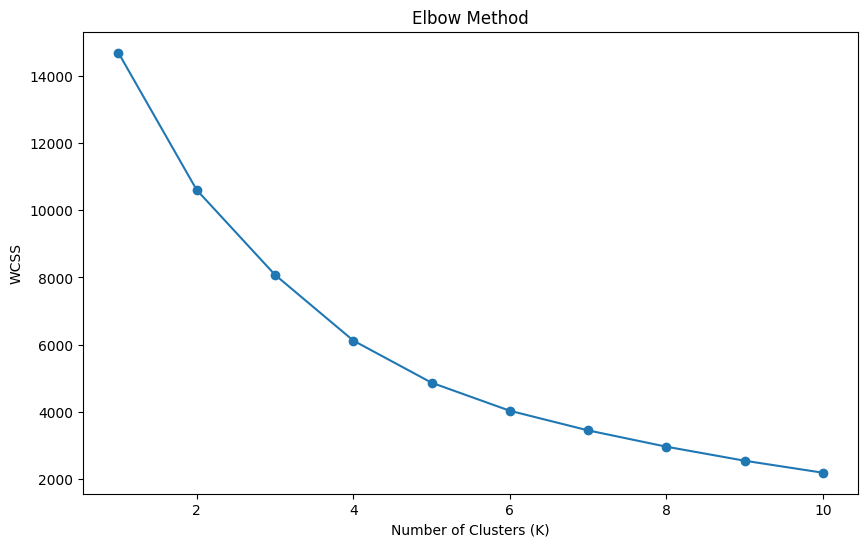

Silhouette Scores:

K = 2 ---> Silhouette Score = 0.24463051943756128
K = 3 ---> Silhouette Score = 0.30426674770288853
K = 4 ---> Silhouette Score = 0.3571173790013799
K = 5 ---> Silhouette Score = 0.3987235370936726
K = 6 ---> Silhouette Score = 0.3760935417543232
K = 7 ---> Silhouette Score = 0.41541117955313206
K = 8 ---> Silhouette Score = 0.43930553239605635
K = 9 ---> Silhouette Score = 0.46676678257618887
K = 10 ---> Silhouette Score = 0.49129751100998614

Best K Value: 10
Best Silhouette Score: 0.49129751100998614
   Rainfall  Temperature  Soil_Moisture   Soil_pH  Nitrogen  Phosphorus  \
0  0.577079     1.528892       0.501549 -0.542526 -1.347283   -0.244281   
1 -0.474170     0.630255      -0.717453  0.331844  0.137897   -1.057842   
2 -0.814329    -0.854449       0.000180  1.206215  0.546834    1.356104   
3 -0.782371     1.528892      -0.451363  0.532949  0.810878    0.144442   
4 -0.803937    -1.225625      -0.226755  0.681592  0.692414    0.871296   

   Irrigation  Crop_

In [1]:
# =========================================
# IMPROVED K-MEANS CLUSTERING
# Automatic Best K Selection
# =========================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


# -----------------------------------------
# Step 1 : Load Final Dataset
# -----------------------------------------

final_df = pd.read_csv("final_selected_features_dataset.csv")

print(final_df.head())


# =========================================
# STEP 2 : ELBOW METHOD
# =========================================

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        init="k-means++",
        max_iter=300,
        n_init=20,
        random_state=42
    )

    kmeans.fit(final_df)

    wcss.append(kmeans.inertia_)


# -----------------------------------------
# Plot Elbow Curve
# -----------------------------------------

plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.show()


# =========================================
# STEP 3 : FIND BEST K USING SILHOUETTE
# =========================================

best_score = -1
best_k = 2

print("Silhouette Scores:\n")

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        init="k-means++",
        max_iter=300,
        n_init=20,
        random_state=42
    )

    labels = kmeans.fit_predict(final_df)

    score = silhouette_score(final_df, labels)

    print(f"K = {k} ---> Silhouette Score = {score}")

    # Save best score
    if score > best_score:
        best_score = score
        best_k = k


# -----------------------------------------
# Print Best K
# -----------------------------------------

print("\nBest K Value:", best_k)
print("Best Silhouette Score:", best_score)


# =========================================
# STEP 4 : TRAIN FINAL MODEL
# =========================================

final_kmeans = KMeans(
    n_clusters=best_k,
    init="k-means++",
    max_iter=300,
    n_init=20,
    random_state=42
)

cluster_labels = final_kmeans.fit_predict(final_df)


# -----------------------------------------
# Add Cluster Labels
# -----------------------------------------

final_df["Cluster"] = cluster_labels

print(final_df.head())


# -----------------------------------------
# Cluster Distribution
# -----------------------------------------

print("\nCluster Distribution:\n")
print(final_df["Cluster"].value_counts())


# =========================================
# STEP 5 : FINAL SILHOUETTE SCORE
# =========================================

final_score = silhouette_score(
    final_df.drop("Cluster", axis=1),
    cluster_labels
)

print("\nFinal Silhouette Score:", final_score)


# =========================================
# STEP 6 : SAVE FINAL DATASET
# =========================================

final_df.to_csv(
    "kmeans_clustered_agriculture_dataset.csv",
    index=False
)

print("\nImproved K-Means Model Training Completed ✅")